# 04 — Feature Selection and Dimensionality Reduction (Review 2)

**Owner: Akilan (modelling)** — uses only the **training** patients. The test set is not loaded here.

**Plan.** The engineered feature matrix has ~125 columns, many of them redundant. We compare:

1. **Feature selection** — (a) a correlation filter to remove near-duplicates, then (b) an embedded ranking from an XGBoost model (gain importance), choosing the smallest top-*k* that keeps validation performance.
2. **Dimensionality reduction** — PCA (95 % variance), then XGBoost and Logistic Regression on the components.

To keep memory low, the training rows keep all positive hours and 40 % of the negative hours (`NEG_FRACTION`); validation and test rows are never sampled.

Everything is scored with patient-level validation (a slice of the training patients), using **AUPRC** and **ROC-AUC**
because accuracy is meaningless at a 1.8 % positive rate. The winner goes to notebook 05.

In [1]:
# CELL 1 — Imports and paths
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import gc
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

# All paths are relative to the repository root, so the notebook works on any machine
def find_project_root():
    here = Path.cwd()
    for folder in [here, here.parent]:
        if (folder / "notebooks").is_dir():
            return folder
    raise FileNotFoundError("Open this notebook from the repository root or from the notebooks/ folder.")

PROJECT_ROOT = find_project_root()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR = RESULTS_DIR / "figures"
for folder in [METRICS_DIR, FIGURES_DIR]:
    os.makedirs(folder, exist_ok=True)

CORR_LIMIT = 0.98     # features more correlated than this are treated as duplicates
SAMPLE_ROWS = 200_000 # rows used for correlation and PCA fitting (speed)

# Memory saver: keep every sepsis-positive hour but only this share of the negative hours
# in the training rows. Set to 1.0 to use everything (needs roughly 16 GB of free RAM).
# Validation and test rows are never sampled.
NEG_FRACTION = 0.4

In [2]:
# CELL 2 — Load TRAINING data only
train = joblib.load(os.path.join(PROC_DIR, "review2_train.joblib"))

X_train = train["X"]
y_train = train["y"]
meta_train = train["meta"]
raw_cols = train["raw_columns"]

print("X_train:", X_train.shape)
print("Number of features:", X_train.shape[1])

X_train: (931285, 124)
Number of features: 124


In [3]:
# CELL 3 — Patient-level validation split inside the training set
# Rows of one patient must stay together, otherwise validation scores are inflated.

patient_outcome = (
    meta_train.assign(y=y_train.values)
    .groupby("Patient_Key")["y"].max()
    .reset_index()
)

fit_patients, val_patients = train_test_split(
    patient_outcome,
    test_size=0.15,
    random_state=42,
    stratify=patient_outcome["y"],
)

fit_keys = set(fit_patients["Patient_Key"])
val_keys = set(val_patients["Patient_Key"])

is_fit = meta_train["Patient_Key"].isin(fit_keys).values
is_val = meta_train["Patient_Key"].isin(val_keys).values

# Validation rows are kept in full
X_val, y_val = X_train[is_val], y_train[is_val]

# Fit rows: all positive hours + a random share of the negative hours
rng = np.random.default_rng(42)
keep_negative = rng.random(len(y_train)) < NEG_FRACTION
keep_fit = is_fit & ((y_train.values == 1) | keep_negative)

X_fit, y_fit = X_train[keep_fit], y_train[keep_fit]

# Free the big original matrices - they are not needed any more
del train, X_train, y_train, meta_train, rng, keep_negative
gc.collect()

print("Fit rows       :", X_fit.shape[0], "| positives:", int(y_fit.sum()), "| patients:", len(fit_keys))
print("Validation rows:", X_val.shape[0], "| positives:", int(y_val.sum()), "| patients:", len(val_keys))
print("Patient overlap:", len(fit_keys & val_keys))

# Same split is reused in notebook 05
joblib.dump({"fit_keys": fit_keys, "val_keys": val_keys}, os.path.join(PROC_DIR, "review2_split.joblib"))

Fit rows       : 324860 | positives: 13387 | patients: 20629
Validation rows: 139219 | positives: 2346 | patients: 3641
Patient overlap: 0


['d:\\SepsiChronos HDA\\data\\processed\\review2_split.joblib']

In [4]:
# CELL 4 — Helper functions
negatives = (y_fit == 0).sum()
positives = (y_fit == 1).sum()

# Square-root weighting: boosts the rare class without over-distorting probabilities
SPW = float(np.sqrt(negatives / positives))
print("scale_pos_weight used:", round(SPW, 2))

def make_xgb():
    return XGBClassifier(
        n_estimators=250,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=SPW,
        importance_type="gain",
        tree_method="hist",
        eval_metric="aucpr",
        early_stopping_rounds=25,
        n_jobs=-1,
        random_state=42,
    )

def fit_and_score(X_a, X_b):
    """Train on the fit part, score on the validation part."""
    model = make_xgb()
    model.fit(X_a, y_fit, eval_set=[(X_b, y_val)], verbose=False)
    prob = model.predict_proba(X_b)[:, 1]
    return model, roc_auc_score(y_val, prob), average_precision_score(y_val, prob)

scale_pos_weight used: 4.82


In [5]:
# CELL 5 — Feature selection step 1: remove constant and near-duplicate features
sample = X_fit.sample(n=min(SAMPLE_ROWS, len(X_fit)), random_state=42)

constant_cols = [c for c in X_fit.columns if sample[c].nunique() <= 1]

corr = sample.drop(columns=constant_cols).corr().abs()
upper_triangle = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
correlated_cols = [c for c in upper_triangle.columns if (upper_triangle[c] > CORR_LIMIT).any()]

filtered_cols = [c for c in X_fit.columns if c not in constant_cols and c not in correlated_cols]

print("Constant features removed  :", constant_cols)
print("Near-duplicate features removed (|r| >", CORR_LIMIT, "):", len(correlated_cols))
print(correlated_cols)
print("\nFeatures before:", X_fit.shape[1])
print("Features after :", len(filtered_cols))

Constant features removed  : []
Near-duplicate features removed (|r| > 0.98 ): 5
['Alkalinephos_hrs_since', 'Creatinine_hrs_since', 'Bilirubin_total_hrs_since', 'Platelets_hrs_since', 'Unit2']

Features before: 124
Features after : 119


All filtered features -> Val ROC-AUC: 0.8290 | Val AUPRC: 0.1142


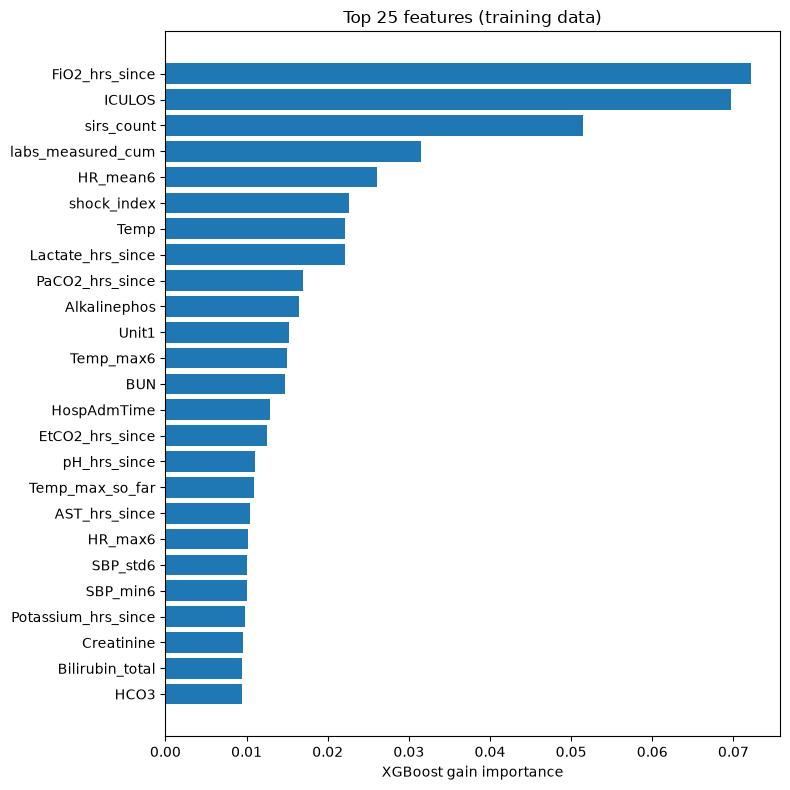

In [6]:
# CELL 6 — Feature selection step 2: rank features with XGBoost (gain importance)
model_all, auc_all, auprc_all = fit_and_score(X_fit[filtered_cols], X_val[filtered_cols])

importance = pd.Series(model_all.feature_importances_, index=filtered_cols)
importance = importance.sort_values(ascending=False)

print("All filtered features -> Val ROC-AUC: %.4f | Val AUPRC: %.4f" % (auc_all, auprc_all))

top = importance.head(25).iloc[::-1]

plt.figure(figsize=(8, 8))
plt.barh(top.index, top.values)
plt.xlabel("XGBoost gain importance")
plt.title("Top 25 features (training data)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "review2_feature_importance_top25.png"), dpi=300, bbox_inches="tight")
plt.show()

importance.to_frame("Gain_importance").to_csv(os.path.join(METRICS_DIR, "review2_feature_ranking.csv"))

top  10 features -> ROC-AUC 0.7966 | AUPRC 0.1190
top  15 features -> ROC-AUC 0.8128 | AUPRC 0.1220
top  20 features -> ROC-AUC 0.8035 | AUPRC 0.1133
top  30 features -> ROC-AUC 0.8216 | AUPRC 0.1124
top  40 features -> ROC-AUC 0.8148 | AUPRC 0.1146
top  60 features -> ROC-AUC 0.8230 | AUPRC 0.1158
top  80 features -> ROC-AUC 0.8341 | AUPRC 0.1213
top 119 features -> ROC-AUC 0.8237 | AUPRC 0.1119

Chosen k: 15


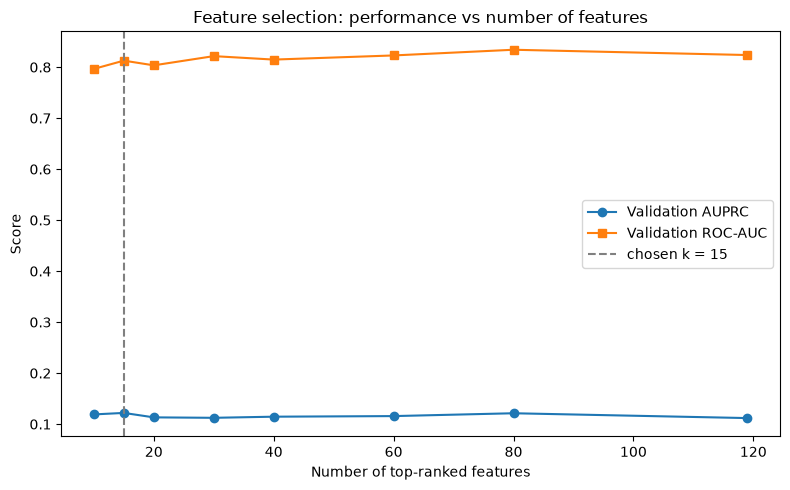

In [7]:
# CELL 7 — How many features do we need? Validate the top-k subsets
k_values = [10, 15, 20, 30, 40, 60, 80, len(importance)]
k_values = sorted(set(k for k in k_values if k <= len(importance)))

k_rows = []

for k in k_values:
    cols = list(importance.index[:k])
    model_k, auc_k, auprc_k = fit_and_score(X_fit[cols], X_val[cols])
    k_rows.append({"k": k, "Val_ROC_AUC": auc_k, "Val_AUPRC": auprc_k})
    print(f"top {k:3d} features -> ROC-AUC {auc_k:.4f} | AUPRC {auprc_k:.4f}")

k_results = pd.DataFrame(k_rows)

# Choose the smallest k that keeps at least 99% of the best validation AUPRC
best_auprc = k_results["Val_AUPRC"].max()
good_enough = k_results[k_results["Val_AUPRC"] >= 0.99 * best_auprc]
best_k = int(good_enough["k"].min())

selected_features = list(importance.index[:best_k])
print("\nChosen k:", best_k)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_results["k"], k_results["Val_AUPRC"], marker="o", label="Validation AUPRC")
ax.plot(k_results["k"], k_results["Val_ROC_AUC"], marker="s", label="Validation ROC-AUC")
ax.axvline(best_k, linestyle="--", color="gray", label=f"chosen k = {best_k}")
ax.set_xlabel("Number of top-ranked features")
ax.set_ylabel("Score")
ax.set_title("Feature selection: performance vs number of features")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "review2_feature_selection_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

Features going into PCA : 119
Components for 95% variance: 71


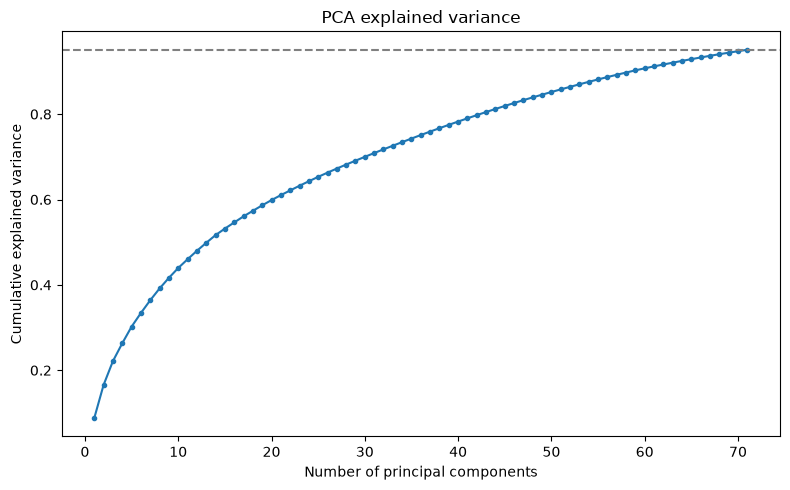

PCA matrices: (324860, 71) (139219, 71)


In [8]:
# CELL 8 — Dimensionality reduction: PCA on standardized features
# Medians and scaler come from the FIT rows only.

medians = X_fit[filtered_cols].median()

sample_filled = sample[filtered_cols].fillna(medians)

scaler = StandardScaler()
scaler.fit(sample_filled)

pca = PCA(n_components=0.95, svd_solver="full", random_state=42)
pca.fit(scaler.transform(sample_filled))

print("Features going into PCA :", len(filtered_cols))
print("Components for 95% variance:", pca.n_components_)

cumulative = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative) + 1), cumulative, marker="o", markersize=3)
plt.axhline(0.95, linestyle="--", color="gray")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "review2_pca_explained_variance.png"), dpi=300, bbox_inches="tight")
plt.show()

def pca_transform(X, chunk=200_000):
    parts = []
    for start in range(0, len(X), chunk):
        block = X[filtered_cols].iloc[start:start + chunk].fillna(medians)
        parts.append(pca.transform(scaler.transform(block)).astype("float32"))
    return np.vstack(parts)

X_fit_pca = pca_transform(X_fit)
X_val_pca = pca_transform(X_val)
print("PCA matrices:", X_fit_pca.shape, X_val_pca.shape)

In [9]:
# CELL 9 — Score PCA with XGBoost and Logistic Regression
model_pca_xgb, auc_pca_xgb, auprc_pca_xgb = fit_and_score(X_fit_pca, X_val_pca)

lr_pca = LogisticRegression(class_weight="balanced", max_iter=300)
lr_pca.fit(X_fit_pca, y_fit)
prob_lr_pca = lr_pca.predict_proba(X_val_pca)[:, 1]
auc_pca_lr = roc_auc_score(y_val, prob_lr_pca)
auprc_pca_lr = average_precision_score(y_val, prob_lr_pca)

print("PCA + XGBoost -> ROC-AUC %.4f | AUPRC %.4f" % (auc_pca_xgb, auprc_pca_xgb))
print("PCA + LogReg  -> ROC-AUC %.4f | AUPRC %.4f" % (auc_pca_lr, auprc_pca_lr))

PCA + XGBoost -> ROC-AUC 0.7552 | AUPRC 0.0738
PCA + LogReg  -> ROC-AUC 0.7304 | AUPRC 0.0668


,Approach,Features,Val_ROC_AUC,Val_AUPRC
0,Raw 40 features (Review 1 inputs),40,0.8276,0.1084
1,All engineered (after correlation filter),119,0.8290,0.1142
2,Feature selection (top-k by XGBoost gain),15,0.8128,0.1220
3,PCA (95% variance) + XGBoost,71,0.7552,0.0738
4,PCA (95% variance) + Logistic Regression,71,0.7304,0.0668


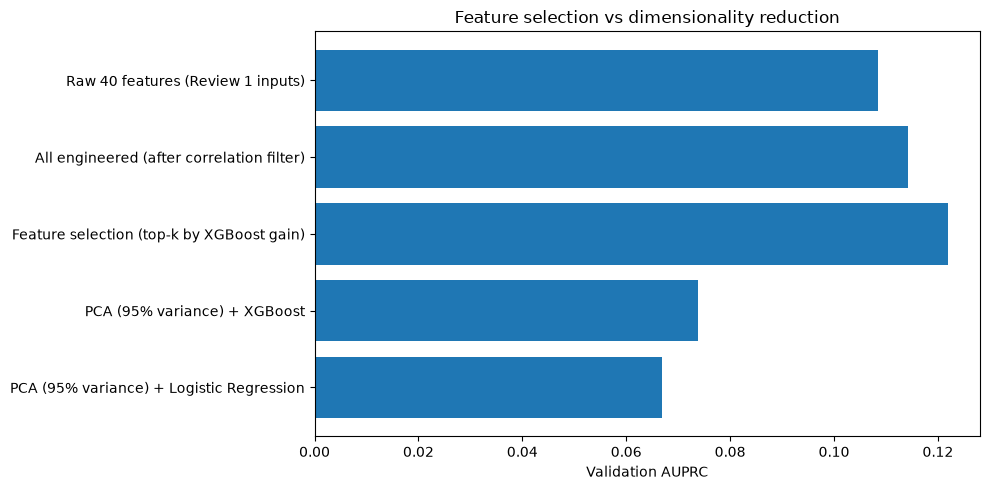

Best on validation AUPRC: Feature selection (top-k by XGBoost gain) -> 0.122


In [10]:
# CELL 10 — Validation comparison: raw vs selected vs PCA
_, auc_raw, auprc_raw = fit_and_score(X_fit[raw_cols], X_val[raw_cols])
selected_row = k_results[k_results["k"] == best_k].iloc[0]

comparison = pd.DataFrame([
    {"Approach": "Raw 40 features (Review 1 inputs)", "Features": len(raw_cols),
     "Val_ROC_AUC": auc_raw, "Val_AUPRC": auprc_raw},
    {"Approach": "All engineered (after correlation filter)", "Features": len(filtered_cols),
     "Val_ROC_AUC": auc_all, "Val_AUPRC": auprc_all},
    {"Approach": "Feature selection (top-k by XGBoost gain)", "Features": best_k,
     "Val_ROC_AUC": selected_row["Val_ROC_AUC"], "Val_AUPRC": selected_row["Val_AUPRC"]},
    {"Approach": "PCA (95% variance) + XGBoost", "Features": int(pca.n_components_),
     "Val_ROC_AUC": auc_pca_xgb, "Val_AUPRC": auprc_pca_xgb},
    {"Approach": "PCA (95% variance) + Logistic Regression", "Features": int(pca.n_components_),
     "Val_ROC_AUC": auc_pca_lr, "Val_AUPRC": auprc_pca_lr},
])

comparison = comparison.round(4)
display(comparison)

comparison.to_csv(os.path.join(METRICS_DIR, "review2_selection_vs_pca_validation.csv"), index=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(comparison["Approach"], comparison["Val_AUPRC"])
ax.invert_yaxis()
ax.set_xlabel("Validation AUPRC")
ax.set_title("Feature selection vs dimensionality reduction")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "review2_selection_vs_pca.png"), dpi=300, bbox_inches="tight")
plt.show()

best_row = comparison.sort_values("Val_AUPRC", ascending=False).iloc[0]
print("Best on validation AUPRC:", best_row["Approach"], "->", best_row["Val_AUPRC"])

In [11]:
# CELL 11 — Save everything notebook 05 needs
feature_sets = {
    "raw_cols": raw_cols,
    "filtered_cols": filtered_cols,
    "selected_features": selected_features,
    "best_k": best_k,
}

with open(os.path.join(PROC_DIR, "review2_feature_sets.json"), "w") as f:
    json.dump(feature_sets, f, indent=2)

joblib.dump(
    {"medians": medians, "scaler": scaler, "pca": pca, "cols": filtered_cols},
    os.path.join(PROC_DIR, "review2_pca_pipeline.joblib"),
    compress=3,
)

print("Selected features (%d):" % len(selected_features))
print(selected_features)
print("\nSaved feature sets and PCA pipeline to:", PROC_DIR.relative_to(PROJECT_ROOT))

Selected features (15):
['FiO2_hrs_since', 'ICULOS', 'sirs_count', 'labs_measured_cum', 'HR_mean6', 'shock_index', 'Temp', 'Lactate_hrs_since', 'PaCO2_hrs_since', 'Alkalinephos', 'Unit1', 'Temp_max6', 'BUN', 'HospAdmTime', 'EtCO2_hrs_since']

Saved feature sets and PCA pipeline to: data\processed
